# Phase 3 Experiments — Graph Neural Networks for Drug Safety Prediction

**Project:** Graph and Geometric Deep Learning for Predicting Drug Safety Properties  
**University:** Aristotle University of Thessaloniki (AUTH)

---

| Component | Details |
|-----------|---------|
| **GNN Architectures** | GCN, GIN, GAT, GraphSAGE, GINe (with bond-level edge features) |
| **Classical Baselines** | Random Forest, XGBoost (Morgan fingerprints, 1024-bit) |
| **Datasets** | ClinTox (binary classification, imbalanced), LD50_Zhu (regression) |
| **Evaluation** | 3 scaffold split seeds (42, 123, 456) — mean ± std |
| **Ablation** | GIN vs GINe — quantifying bond feature contribution |

All model code is imported from `src/` — no code duplication.

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch_geometric
from torch_geometric.loader import DataLoader
from sklearn.metrics import (
    roc_auc_score, f1_score, roc_curve, r2_score, mean_squared_error,
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from rdkit import Chem
from rdkit.Chem import AllChem
from tdc.single_pred import Tox

from src import (
    ATOM_FEAT_DIM, BOND_FEAT_DIM, build_dataset,
    GCN, GIN, GAT, GraphSAGE, GINe,
    train_model, evaluate, evaluate_regression,
)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
sns.set_palette("Set2")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | PyG {torch_geometric.__version__} | Device: {device}")
print(f"Atom features: {ATOM_FEAT_DIM} | Bond features: {BOND_FEAT_DIM}")

PyTorch 2.11.0+cpu | PyG 2.7.0 | Device: cpu
Atom features: 141 | Bond features: 6


In [7]:
# ── Experiment Configuration ──────────────────────────────────────────────

SEEDS = [42, 123, 456]
BATCH_SIZE = 64
NUM_EPOCHS = 100
PATIENCE = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 128
NUM_LAYERS = 3
DROPOUT = 0.3

DATA_PATH = "../data"
MODELS_PATH = "../models"
RESULTS_PATH = "../results"
PLOTS_PATH = "../plots"

for d in [MODELS_PATH, RESULTS_PATH, PLOTS_PATH]:
    os.makedirs(d, exist_ok=True)

# Model registry: name -> (class, extra kwargs)
MODEL_REGISTRY = {
    "GCN": (GCN, {}),
    "GIN": (GIN, {}),
    "GAT": (GAT, {"heads": 4}),
    "GraphSAGE": (GraphSAGE, {}),
    "GINe": (GINe, {"edge_dim": BOND_FEAT_DIM}),
}

print(f"Seeds: {SEEDS}")
print(f"Models: {list(MODEL_REGISTRY.keys())}")
print(f"Epochs: {NUM_EPOCHS} | Patience: {PATIENCE} | LR: {LR}")

Seeds: [42, 123, 456]
Models: ['GCN', 'GIN', 'GAT', 'GraphSAGE', 'GINe']
Epochs: 100 | Patience: 15 | LR: 0.001


---
## 1. Data Loading & Featurization Helpers

In [8]:
def load_tdc_dataset(name, seed, path=DATA_PATH):
    """Load a TDC Tox dataset with scaffold split."""
    data = Tox(name=name, path=path)
    split = data.get_split(method="scaffold", seed=seed)
    return split["train"], split["valid"], split["test"]


def prepare_loaders(train_df, val_df, test_df, batch_size=BATCH_SIZE):
    """Featurize DataFrames and return DataLoaders."""
    train_data = build_dataset(train_df, desc="  Train")
    val_data = build_dataset(val_df, desc="  Val")
    test_data = build_dataset(test_df, desc="  Test")
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size)
    test_loader = DataLoader(test_data, batch_size=batch_size)
    return train_loader, val_loader, test_loader


def compute_pos_weight(train_df):
    """Compute pos_weight for imbalanced binary classification."""
    counts = train_df["Y"].value_counts()
    neg, pos = counts.get(0, 0), counts.get(1, 0)
    return float(neg / pos) if pos > 0 else 1.0


def smiles_to_fingerprints(smiles_list, n_bits=1024, radius=2):
    """Convert list of SMILES to Morgan fingerprint matrix."""
    fps, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
            fps.append(np.array(fp))
            valid_idx.append(i)
    return np.array(fps), valid_idx


print("Helper functions defined.")

Helper functions defined.


---
## 2. Multi-Seed GNN Training

In [9]:
def run_gnns_multi_seed(dataset_name, task, seeds=SEEDS, use_pos_weight=False):
    """Run all 5 GNN architectures with multiple scaffold split seeds.

    Returns
    -------
    all_results : dict  {model_name: [test_results_per_seed]}
    all_histories : dict {(model_name, seed): history}
    last_models : dict  {model_name: trained_model} (from last seed)
    """
    all_results = {name: [] for name in MODEL_REGISTRY}
    all_histories = {}
    last_models = {}

    for seed in seeds:
        print(f"\n{'#' * 70}")
        print(f"# SEED {seed} — {dataset_name} ({task})")
        print(f"{'#' * 70}")

        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        train_df, val_df, test_df = load_tdc_dataset(dataset_name, seed)
        train_loader, val_loader, test_loader = prepare_loaders(
            train_df, val_df, test_df
        )

        pw = (
            compute_pos_weight(train_df)
            if (task == "classification" and use_pos_weight)
            else None
        )

        for model_name, (model_class, extra_kwargs) in MODEL_REGISTRY.items():
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            model, history, test_res = train_model(
                model_class=model_class,
                model_name=f"{model_name} (seed={seed})",
                train_loader=train_loader,
                val_loader=val_loader,
                test_loader=test_loader,
                device=device,
                in_dim=ATOM_FEAT_DIM,
                num_epochs=NUM_EPOCHS,
                lr=LR,
                weight_decay=WEIGHT_DECAY,
                patience=PATIENCE,
                pos_weight=pw,
                task=task,
                hidden_dim=HIDDEN_DIM,
                num_layers=NUM_LAYERS,
                dropout=DROPOUT,
                **extra_kwargs,
            )

            test_res["Seed"] = seed
            test_res["Model"] = model_name
            all_results[model_name].append(test_res)
            all_histories[(model_name, seed)] = history
            last_models[model_name] = model

    return all_results, all_histories, last_models

---
## 3. ClinTox — Binary Classification (Imbalanced)

- **1,484 molecules**, ~8% positive (toxic)
- Scaffold split, 3 seeds
- `pos_weight` to handle class imbalance
- Metrics: ROC AUC, F1

In [10]:
clintox_results, clintox_histories, clintox_models = run_gnns_multi_seed(
    dataset_name="ClinTox",
    task="classification",
    use_pos_weight=True,
)


######################################################################
# SEED 42 — ClinTox (classification)
######################################################################


Found local copy...
Loading...
Done!
100%|██████████| 1478/1478 [00:00<00:00, 2096.73it/s]


  Train: 1,034 graphs built (0 skipped)
  Val: 147 graphs built (0 skipped)
  Test: 297 graphs built (0 skipped)

Training: GCN (seed=42)  [classification]
Using pos_weight=13.56 for class imbalance
Epoch 01/100  Train Loss: 1.2867 | Val Loss: 1.6887 | Val AUC: 0.4695 | Val F1: 0.2222 | LR: 1.0e-03  * Best
Epoch 02/100  Train Loss: 1.1390 | Val Loss: 1.6117 | Val AUC: 0.5740 | Val F1: 0.2254 | LR: 1.0e-03  * Best
Epoch 03/100  Train Loss: 1.0657 | Val Loss: 1.5067 | Val AUC: 0.6586 | Val F1: 0.2679 | LR: 1.0e-03  * Best
Epoch 04/100  Train Loss: 0.9806 | Val Loss: 1.3504 | Val AUC: 0.7613 | Val F1: 0.3297 | LR: 1.0e-03  * Best
Epoch 05/100  Train Loss: 0.8844 | Val Loss: 1.2387 | Val AUC: 0.7876 | Val F1: 0.3696 | LR: 1.0e-03  * Best
Epoch 06/100  Train Loss: 0.7960 | Val Loss: 1.1146 | Val AUC: 0.8428 | Val F1: 0.4304 | LR: 1.0e-03  * Best
Epoch 07/100  Train Loss: 0.7331 | Val Loss: 0.9867 | Val AUC: 0.8762 | Val F1: 0.4324 | LR: 1.0e-03  * Best
Epoch 09/100  Train Loss: 0.6722 | Val

Found local copy...
Loading...
Done!


Epoch 70/100  Train Loss: 0.3310 | Val Loss: 1.1629 | Val AUC: 0.9215 | Val F1: 0.6122 | LR: 3.1e-05

Early stopping at epoch 70 (no improvement for 15 epochs)

Restored best model (Val AUC: 0.9324)

--- Test Results: GINe (seed=42) ---
Accuracy: 0.7778 | F1: 0.3400 | ROC AUC: 0.8487
              precision    recall  f1-score   support

    Negative       0.97      0.78      0.87       273
    Positive       0.22      0.71      0.34        24

    accuracy                           0.78       297
   macro avg       0.60      0.75      0.60       297
weighted avg       0.91      0.78      0.82       297


######################################################################
# SEED 123 — ClinTox (classification)
######################################################################


...

  Train: 1,034 graphs built (0 skipped)
  Val: 147 graphs built (0 skipped)
  Test: 297 graphs built (0 skipped)

Training: GCN (seed=123)  [classification]
Using pos_weight=13.36 for class imbalance
Epoch 01/100  Train Loss: 1.2787 | Val Loss: 1.4445 | Val AUC: 0.5930 | Val F1: 0.1687 | LR: 1.0e-03  * Best
Epoch 02/100  Train Loss: 1.2154 | Val Loss: 1.4017 | Val AUC: 0.7176 | Val F1: 0.1884 | LR: 1.0e-03  * Best
Epoch 03/100  Train Loss: 1.1366 | Val Loss: 1.2930 | Val AUC: 0.8330 | Val F1: 0.2047 | LR: 1.0e-03  * Best
Epoch 04/100  Train Loss: 1.0021 | Val Loss: 1.0966 | Val AUC: 0.8840 | Val F1: 0.3095 | LR: 1.0e-03  * Best
Epoch 05/100  Train Loss: 0.9117 | Val Loss: 0.9409 | Val AUC: 0.8863 | Val F1: 0.3333 | LR: 1.0e-03  * Best
Epoch 06/100  Train Loss: 0.8285 | Val Loss: 0.8300 | Val AUC: 0.8892 | Val F1: 0.3824 | LR: 1.0e-03  * Best
Epoch 07/100  Train Loss: 0.7382 | Val Loss: 0.7879 | Val AUC: 0.9070 | Val F1: 0.3824 | LR: 1.0e-03  * Best
Epoch 08/100  Train Loss: 0.7469 | Va

Found local copy...
Loading...
Done!



Early stopping at epoch 34 (no improvement for 15 epochs)

Restored best model (Val AUC: 0.9374)

--- Test Results: GINe (seed=123) ---
Accuracy: 0.7306 | F1: 0.3443 | ROC AUC: 0.8720
              precision    recall  f1-score   support

    Negative       0.97      0.73      0.83       270
    Positive       0.22      0.78      0.34        27

    accuracy                           0.73       297
   macro avg       0.60      0.75      0.59       297
weighted avg       0.90      0.73      0.79       297


######################################################################
# SEED 456 — ClinTox (classification)
######################################################################


100%|██████████| 1478/1478 [00:00<00:00, 1787.93it/s]


  Train: 1,034 graphs built (0 skipped)
  Val: 147 graphs built (0 skipped)
  Test: 297 graphs built (0 skipped)

Training: GCN (seed=456)  [classification]
Using pos_weight=12.79 for class imbalance
Epoch 01/100  Train Loss: 1.2744 | Val Loss: 1.3986 | Val AUC: 0.6340 | Val F1: 0.1625 | LR: 1.0e-03  * Best
Epoch 02/100  Train Loss: 1.1694 | Val Loss: 1.3827 | Val AUC: 0.6484 | Val F1: 0.1646 | LR: 1.0e-03  * Best
Epoch 03/100  Train Loss: 1.0619 | Val Loss: 1.2875 | Val AUC: 0.7402 | Val F1: 0.1875 | LR: 1.0e-03  * Best
Epoch 04/100  Train Loss: 0.9472 | Val Loss: 1.1765 | Val AUC: 0.7712 | Val F1: 0.2750 | LR: 1.0e-03  * Best
Epoch 05/100  Train Loss: 0.8377 | Val Loss: 1.1055 | Val AUC: 0.7799 | Val F1: 0.3056 | LR: 1.0e-03  * Best
Epoch 10/100  Train Loss: 0.6941 | Val Loss: 1.6428 | Val AUC: 0.7035 | Val F1: 0.2571 | LR: 1.0e-03
Epoch 15/100  Train Loss: 0.5192 | Val Loss: 1.8713 | Val AUC: 0.7179 | Val F1: 0.2540 | LR: 5.0e-04
Epoch 20/100  Train Loss: 0.4691 | Val Loss: 2.1961 |

---
## 4. LD50_Zhu — Regression

- **7,385 molecules**, predict lethal dose (log scale)
- Scaffold split, 3 seeds
- Metrics: R², RMSE

In [11]:
ld50_results, ld50_histories, ld50_models = run_gnns_multi_seed(
    dataset_name="LD50_Zhu",
    task="regression",
)

Downloading...



######################################################################
# SEED 42 — LD50_Zhu (regression)
######################################################################


100%|██████████| 707k/707k [00:00<00:00, 888kiB/s] 
Loading...
Done!
100%|██████████| 7385/7385 [00:02<00:00, 3030.50it/s]


  Train: 5,169 graphs built (0 skipped)
  Val: 738 graphs built (0 skipped)
  Test: 1,478 graphs built (0 skipped)

Training: GCN (seed=42)  [regression]
Epoch 01/100  Train Loss: 1.4615 | Val Loss: 0.9020 | Val R²: -0.1796 | Val RMSE: 0.9497 | LR: 1.0e-03  * Best
Epoch 02/100  Train Loss: 0.6853 | Val Loss: 0.7586 | Val R²: 0.0080 | Val RMSE: 0.8710 | LR: 1.0e-03  * Best
Epoch 03/100  Train Loss: 0.6495 | Val Loss: 0.6811 | Val R²: 0.1093 | Val RMSE: 0.8253 | LR: 1.0e-03  * Best
Epoch 05/100  Train Loss: 0.6344 | Val Loss: 0.6012 | Val R²: 0.2138 | Val RMSE: 0.7754 | LR: 1.0e-03  * Best
Epoch 10/100  Train Loss: 0.5884 | Val Loss: 0.6155 | Val R²: 0.1951 | Val RMSE: 0.7845 | LR: 1.0e-03
Epoch 11/100  Train Loss: 0.5846 | Val Loss: 0.6000 | Val R²: 0.2153 | Val RMSE: 0.7746 | LR: 1.0e-03  * Best
Epoch 15/100  Train Loss: 0.5792 | Val Loss: 0.6021 | Val R²: 0.2126 | Val RMSE: 0.7760 | LR: 1.0e-03
Epoch 16/100  Train Loss: 0.5710 | Val Loss: 0.5700 | Val R²: 0.2546 | Val RMSE: 0.7550 | L

Found local copy...
Loading...
Done!


...

  Train: 5,169 graphs built (0 skipped)
  Val: 738 graphs built (0 skipped)
  Test: 1,478 graphs built (0 skipped)

Training: GCN (seed=123)  [regression]
Epoch 01/100  Train Loss: 1.5804 | Val Loss: 1.5969 | Val R²: -0.2785 | Val RMSE: 1.2637 | LR: 1.0e-03  * Best
Epoch 02/100  Train Loss: 0.7172 | Val Loss: 1.3612 | Val R²: -0.0898 | Val RMSE: 1.1667 | LR: 1.0e-03  * Best
Epoch 04/100  Train Loss: 0.6521 | Val Loss: 1.1608 | Val R²: 0.0706 | Val RMSE: 1.0774 | LR: 1.0e-03  * Best
Epoch 05/100  Train Loss: 0.6568 | Val Loss: 1.5550 | Val R²: -0.2450 | Val RMSE: 1.2470 | LR: 1.0e-03
Epoch 09/100  Train Loss: 0.6243 | Val Loss: 1.1481 | Val R²: 0.0808 | Val RMSE: 1.0715 | LR: 1.0e-03  * Best
Epoch 10/100  Train Loss: 0.6184 | Val Loss: 1.1482 | Val R²: 0.0807 | Val RMSE: 1.0715 | LR: 1.0e-03
Epoch 12/100  Train Loss: 0.5988 | Val Loss: 1.1161 | Val R²: 0.1064 | Val RMSE: 1.0565 | LR: 1.0e-03  * Best
Epoch 15/100  Train Loss: 0.5733 | Val Loss: 1.0313 | Val R²: 0.1743 | Val RMSE: 1.0156 

Found local copy...
Loading...
Done!



--- Test Results: GINe (seed=123) ---
R²: 0.1933 | RMSE: 0.8254

######################################################################
# SEED 456 — LD50_Zhu (regression)
######################################################################


100%|██████████| 7385/7385 [00:02<00:00, 3663.89it/s]


  Train: 5,169 graphs built (0 skipped)
  Val: 738 graphs built (0 skipped)
  Test: 1,478 graphs built (0 skipped)

Training: GCN (seed=456)  [regression]
Epoch 01/100  Train Loss: 1.2604 | Val Loss: 0.8881 | Val R²: 0.0605 | Val RMSE: 0.9424 | LR: 1.0e-03  * Best
Epoch 02/100  Train Loss: 0.6755 | Val Loss: 0.7973 | Val R²: 0.1566 | Val RMSE: 0.8929 | LR: 1.0e-03  * Best
Epoch 03/100  Train Loss: 0.6334 | Val Loss: 0.7734 | Val R²: 0.1818 | Val RMSE: 0.8795 | LR: 1.0e-03  * Best
Epoch 05/100  Train Loss: 0.6036 | Val Loss: 0.7859 | Val R²: 0.1686 | Val RMSE: 0.8865 | LR: 1.0e-03
Epoch 06/100  Train Loss: 0.6093 | Val Loss: 0.7521 | Val R²: 0.2043 | Val RMSE: 0.8673 | LR: 1.0e-03  * Best
Epoch 10/100  Train Loss: 0.5720 | Val Loss: 0.7518 | Val R²: 0.2047 | Val RMSE: 0.8671 | LR: 1.0e-03  * Best
Epoch 11/100  Train Loss: 0.5548 | Val Loss: 0.7488 | Val R²: 0.2078 | Val RMSE: 0.8654 | LR: 1.0e-03  * Best
Epoch 13/100  Train Loss: 0.5323 | Val Loss: 0.7400 | Val R²: 0.2172 | Val RMSE: 0.

---
## 5. Classical Baselines — Random Forest & XGBoost

Morgan fingerprints (1024-bit, radius 2) as molecular representation.  
Train+Val combined (no early stopping needed for tree models).

In [12]:
def run_classical_baselines(dataset_name, task, seeds=SEEDS, n_bits=1024):
    """Run RF and XGBoost on Morgan fingerprints with multi-seed scaffold splits."""
    results = {"RF": [], "XGBoost": []}

    for seed in seeds:
        print(f"\n{'=' * 60}")
        print(f"Classical Baselines — {dataset_name} — seed={seed}")
        print(f"{'=' * 60}")

        train_df, val_df, test_df = load_tdc_dataset(dataset_name, seed)
        trainval_df = pd.concat([train_df, val_df], ignore_index=True)

        X_train, idx_train = smiles_to_fingerprints(
            trainval_df["Drug"].tolist(), n_bits
        )
        y_train = trainval_df["Y"].values[idx_train]

        X_test, idx_test = smiles_to_fingerprints(test_df["Drug"].tolist(), n_bits)
        y_test = test_df["Y"].values[idx_test]

        if task == "classification":
            models_dict = {
                "RF": RandomForestClassifier(
                    n_estimators=500, max_depth=None,
                    random_state=seed, n_jobs=-1,
                ),
                "XGBoost": XGBClassifier(
                    n_estimators=500, max_depth=6, learning_rate=0.1,
                    random_state=seed, eval_metric="logloss", verbosity=0,
                ),
            }
            for name, clf in models_dict.items():
                clf.fit(X_train, y_train)
                probs = clf.predict_proba(X_test)[:, 1]
                preds = (probs >= 0.5).astype(int)
                auc = roc_auc_score(y_test, probs)
                f1_val = f1_score(y_test, preds)
                print(f"  {name}: AUC={auc:.4f}, F1={f1_val:.4f}")
                results[name].append({
                    "Model": name, "Seed": seed,
                    "ROC AUC": auc, "F1 Score": f1_val,
                    "probs": probs, "labels": y_test,
                })
        else:
            models_dict = {
                "RF": RandomForestRegressor(
                    n_estimators=500, max_depth=None,
                    random_state=seed, n_jobs=-1,
                ),
                "XGBoost": XGBRegressor(
                    n_estimators=500, max_depth=6, learning_rate=0.1,
                    random_state=seed, verbosity=0,
                ),
            }
            for name, reg in models_dict.items():
                reg.fit(X_train, y_train)
                preds = reg.predict(X_test)
                r2 = r2_score(y_test, preds)
                rmse = float(np.sqrt(mean_squared_error(y_test, preds)))
                print(f"  {name}: R²={r2:.4f}, RMSE={rmse:.4f}")
                results[name].append({
                    "Model": name, "Seed": seed,
                    "R2": r2, "RMSE": rmse,
                    "preds": preds, "labels": y_test,
                })

    return results


clintox_baselines = run_classical_baselines("ClinTox", "classification")
ld50_baselines = run_classical_baselines("LD50_Zhu", "regression")

Found local copy...
Loading...
Done!



Classical Baselines — ClinTox — seed=42


100%|██████████| 1478/1478 [00:00<00:00, 1654.33it/s]


  RF: AUC=0.7315, F1=0.0000


Found local copy...
Loading...
Done!


...

  RF: R²=0.3066, RMSE=0.7653


Found local copy...
Loading...
Done!


  XGBoost: R²=0.3020, RMSE=0.7678

Classical Baselines — LD50_Zhu — seed=456


100%|██████████| 7385/7385 [00:05<00:00, 1382.68it/s]


  RF: R²=0.2652, RMSE=0.8723
  XGBoost: R²=0.2798, RMSE=0.8636


---
## 6. Results Aggregation

In [13]:
def aggregate_clf_results(gnn_results, baseline_results):
    """Aggregate classification results into a summary DataFrame."""
    rows = []
    for model_name, seed_results in {**gnn_results, **baseline_results}.items():
        aucs = [r["ROC AUC"] for r in seed_results]
        f1s = [r["F1 Score"] for r in seed_results]
        rows.append({
            "Model": model_name,
            "AUC (mean)": np.mean(aucs), "AUC (std)": np.std(aucs),
            "F1 (mean)": np.mean(f1s), "F1 (std)": np.std(f1s),
        })
    df = pd.DataFrame(rows).sort_values("AUC (mean)", ascending=False).reset_index(drop=True)
    df["AUC"] = df.apply(lambda r: f"{r['AUC (mean)']:.3f} ± {r['AUC (std)']:.3f}", axis=1)
    df["F1"] = df.apply(lambda r: f"{r['F1 (mean)']:.3f} ± {r['F1 (std)']:.3f}", axis=1)
    return df


def aggregate_reg_results(gnn_results, baseline_results):
    """Aggregate regression results into a summary DataFrame."""
    rows = []
    for model_name, seed_results in {**gnn_results, **baseline_results}.items():
        r2s = [r["R2"] for r in seed_results]
        rmses = [r["RMSE"] for r in seed_results]
        rows.append({
            "Model": model_name,
            "R² (mean)": np.mean(r2s), "R² (std)": np.std(r2s),
            "RMSE (mean)": np.mean(rmses), "RMSE (std)": np.std(rmses),
        })
    df = pd.DataFrame(rows).sort_values("R² (mean)", ascending=False).reset_index(drop=True)
    df["R²"] = df.apply(lambda r: f"{r['R² (mean)']:.3f} ± {r['R² (std)']:.3f}", axis=1)
    df["RMSE"] = df.apply(lambda r: f"{r['RMSE (mean)']:.3f} ± {r['RMSE (std)']:.3f}", axis=1)
    return df


print("=" * 60)
print("ClinTox — Classification Results (3-seed scaffold split)")
print("=" * 60)
clintox_summary = aggregate_clf_results(clintox_results, clintox_baselines)
display(clintox_summary[["Model", "AUC", "F1"]])

print("\n" + "=" * 60)
print("LD50_Zhu — Regression Results (3-seed scaffold split)")
print("=" * 60)
ld50_summary = aggregate_reg_results(ld50_results, ld50_baselines)
display(ld50_summary[["Model", "R²", "RMSE"]])

ClinTox — Classification Results (3-seed scaffold split)


,Model,AUC,F1
0,GIN,0.878 ± 0.028,0.361 ± 0.023
1,GraphSAGE,0.871 ± 0.026,0.327 ± 0.075
2,GAT,0.865 ± 0.010,0.305 ± 0.006
3,GCN,0.861 ± 0.003,0.339 ± 0.020
4,XGBoost,0.855 ± 0.051,0.291 ± 0.154
5,GINe,0.854 ± 0.013,0.344 ± 0.003
6,RF,0.777 ± 0.033,0.000 ± 0.000



LD50_Zhu — Regression Results (3-seed scaffold split)


,Model,R²,RMSE
0,XGBoost,0.305 ± 0.021,0.832 ± 0.046
1,RF,0.277 ± 0.021,0.849 ± 0.062
2,GINe,0.182 ± 0.031,0.903 ± 0.055
3,GCN,0.174 ± 0.036,0.908 ± 0.069
4,GraphSAGE,0.170 ± 0.039,0.911 ± 0.074
5,GAT,0.082 ± 0.064,0.957 ± 0.077
6,GIN,-0.115 ± 0.376,1.030 ± 0.107


---
## 7. Visualization — Training Curves

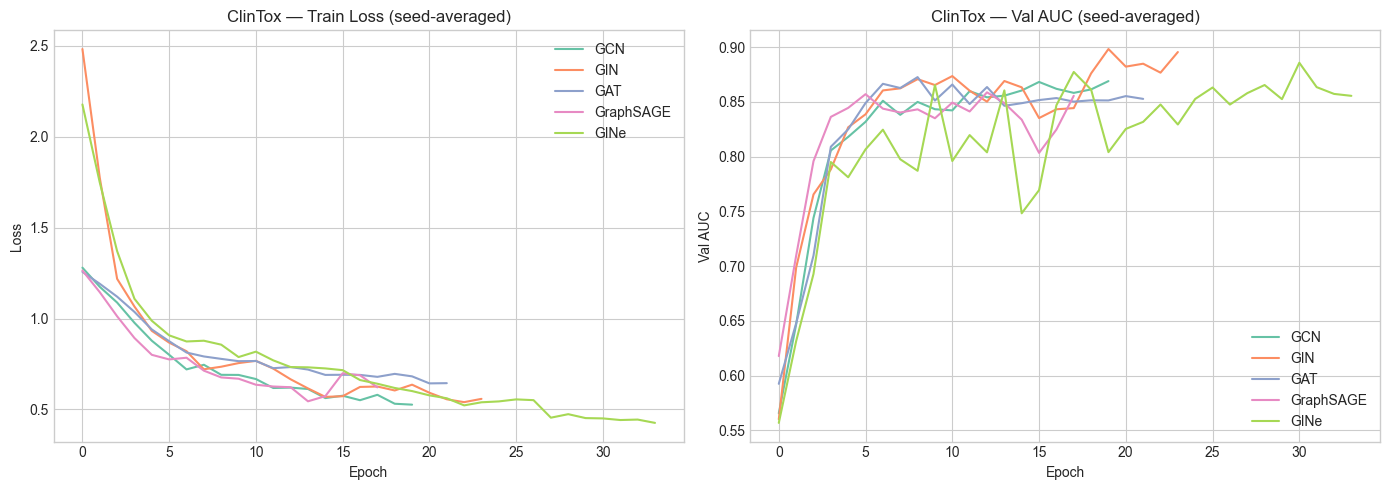

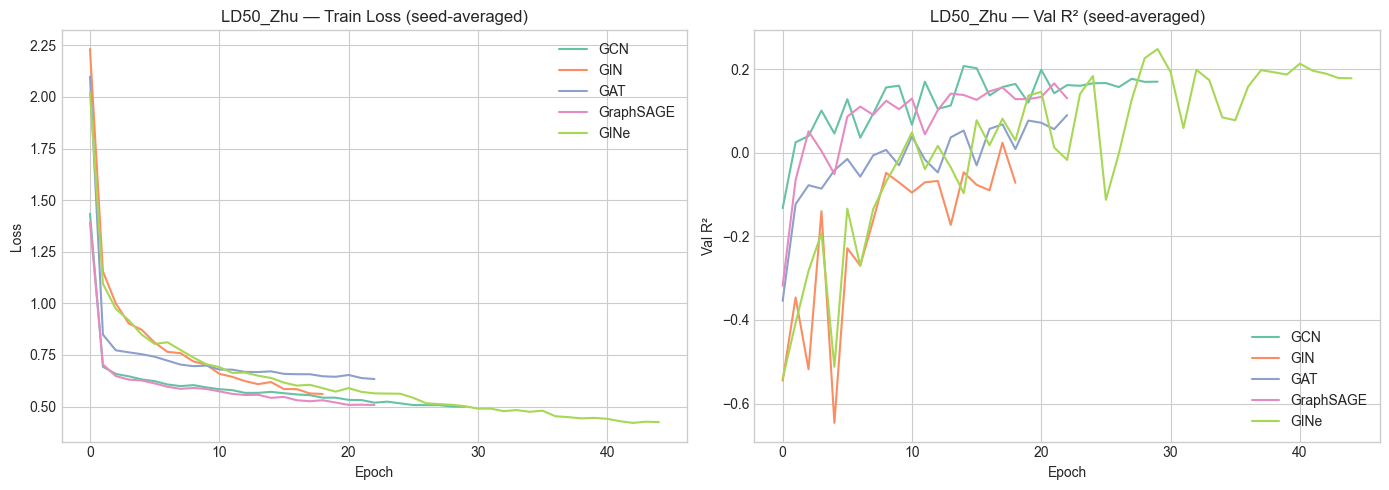

In [14]:
def plot_training_curves(histories, dataset_name, task):
    """Plot seed-averaged training curves for each model."""
    model_names = list(MODEL_REGISTRY.keys())

    if task == "classification":
        metric_key, metric_label = "val_auc", "Val AUC"
    else:
        metric_key, metric_label = "val_r2", "Val R²"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for model_name in model_names:
        seed_hists = [
            histories[(model_name, s)]
            for s in SEEDS
            if (model_name, s) in histories
        ]
        if not seed_hists:
            continue

        min_len = min(len(h["train_loss"]) for h in seed_hists)
        avg_train = np.mean(
            [h["train_loss"][:min_len] for h in seed_hists], axis=0
        )
        avg_metric = np.mean(
            [h[metric_key][:min_len] for h in seed_hists], axis=0
        )

        axes[0].plot(avg_train, label=model_name)
        axes[1].plot(avg_metric, label=model_name)

    axes[0].set_title(f"{dataset_name} — Train Loss (seed-averaged)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].set_title(f"{dataset_name} — {metric_label} (seed-averaged)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel(metric_label)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(
        f"{PLOTS_PATH}/{dataset_name}_training_curves.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()


plot_training_curves(clintox_histories, "ClinTox", "classification")
plot_training_curves(ld50_histories, "LD50_Zhu", "regression")

---
## 8. Visualization — Model Comparison Bar Charts

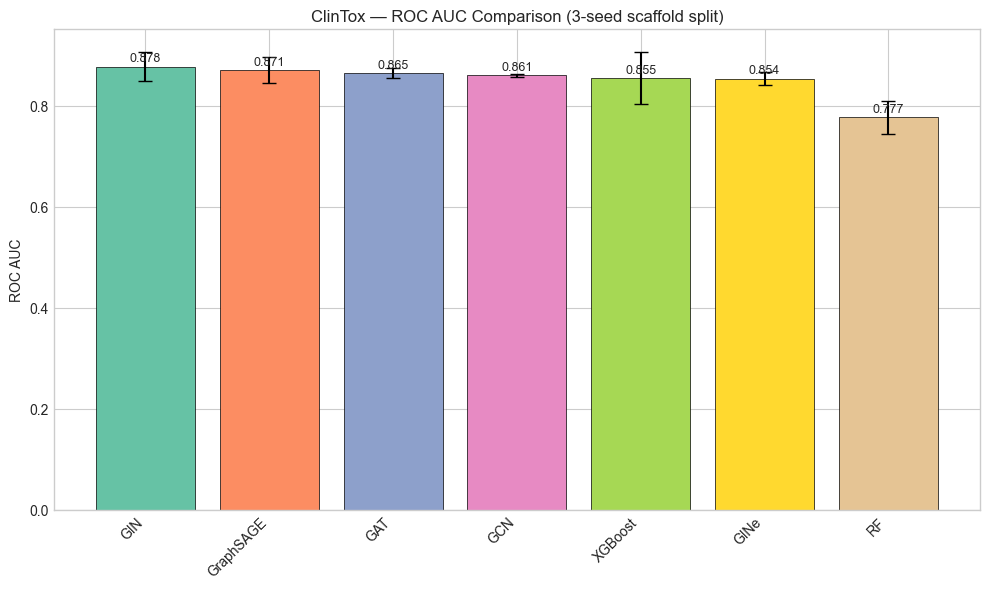

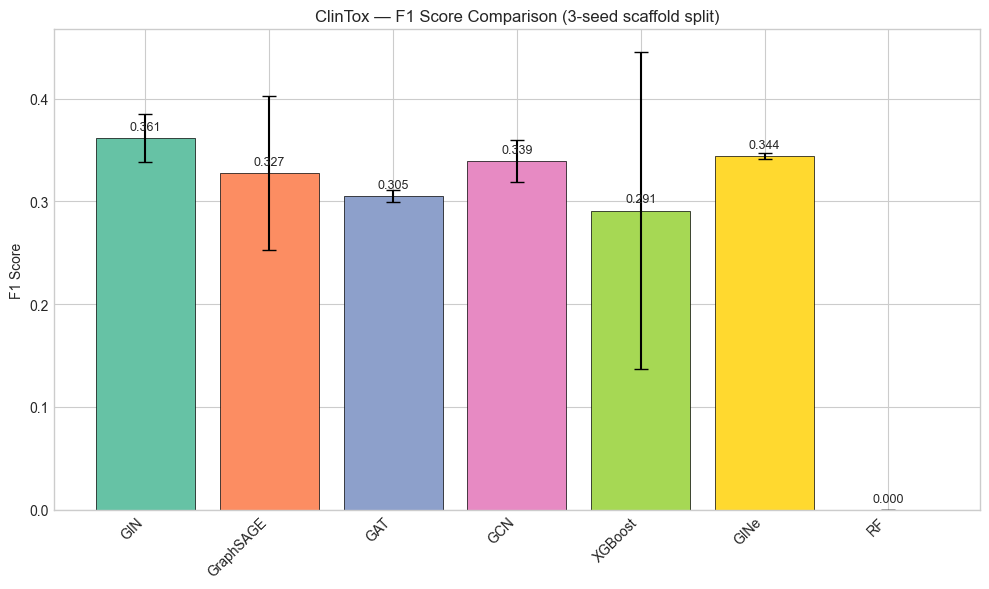

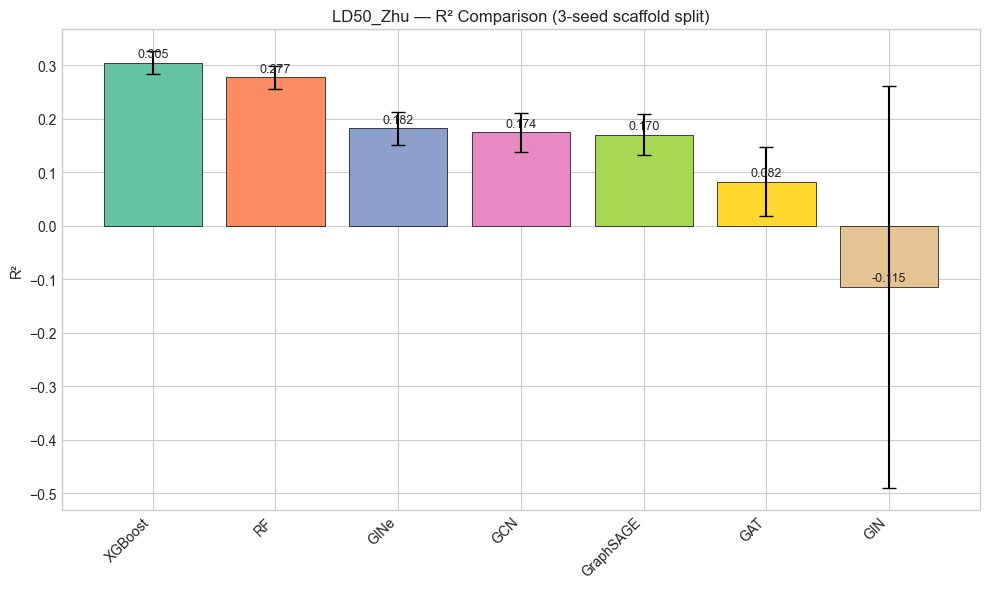

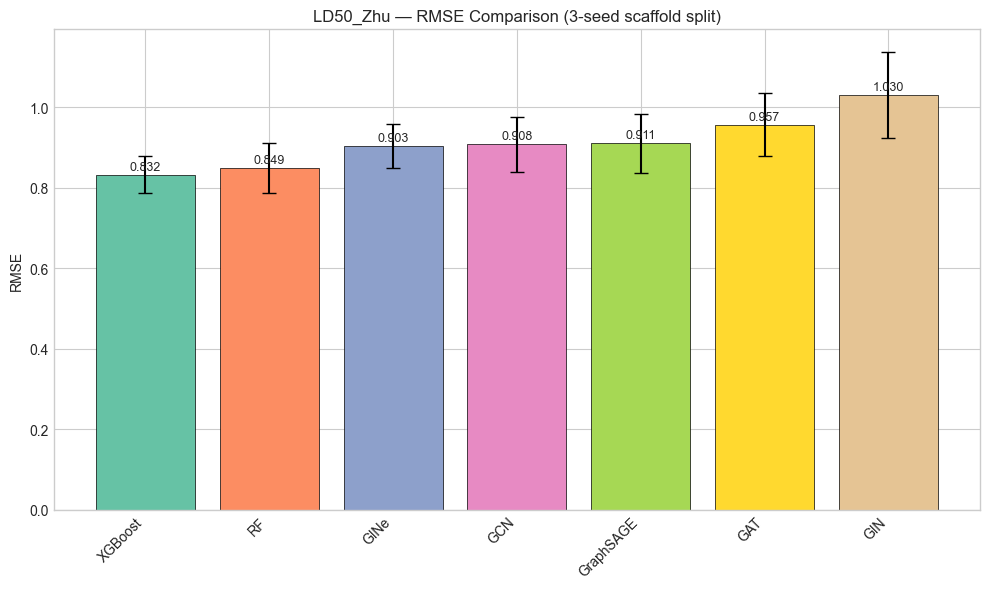

In [15]:
def plot_comparison_bars(summary_df, dataset_name, metric_col, std_col, ylabel):
    """Grouped bar chart comparing all models with error bars."""
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(summary_df))
    colors = sns.color_palette("Set2", len(summary_df))

    bars = ax.bar(
        x, summary_df[metric_col], yerr=summary_df[std_col],
        capsize=5, color=colors, edgecolor="black", linewidth=0.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df["Model"], rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{dataset_name} — {ylabel} Comparison (3-seed scaffold split)")

    for bar, val in zip(bars, summary_df[metric_col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9,
        )

    plt.tight_layout()
    plt.savefig(
        f"{PLOTS_PATH}/{dataset_name}_{ylabel.replace(' ', '_').lower()}_comparison.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()


# ClinTox
plot_comparison_bars(clintox_summary, "ClinTox", "AUC (mean)", "AUC (std)", "ROC AUC")
plot_comparison_bars(clintox_summary, "ClinTox", "F1 (mean)", "F1 (std)", "F1 Score")

# LD50
plot_comparison_bars(ld50_summary, "LD50_Zhu", "R² (mean)", "R² (std)", "R²")
plot_comparison_bars(ld50_summary, "LD50_Zhu", "RMSE (mean)", "RMSE (std)", "RMSE")

---
## 9. ROC Curves — ClinTox (seed=42)

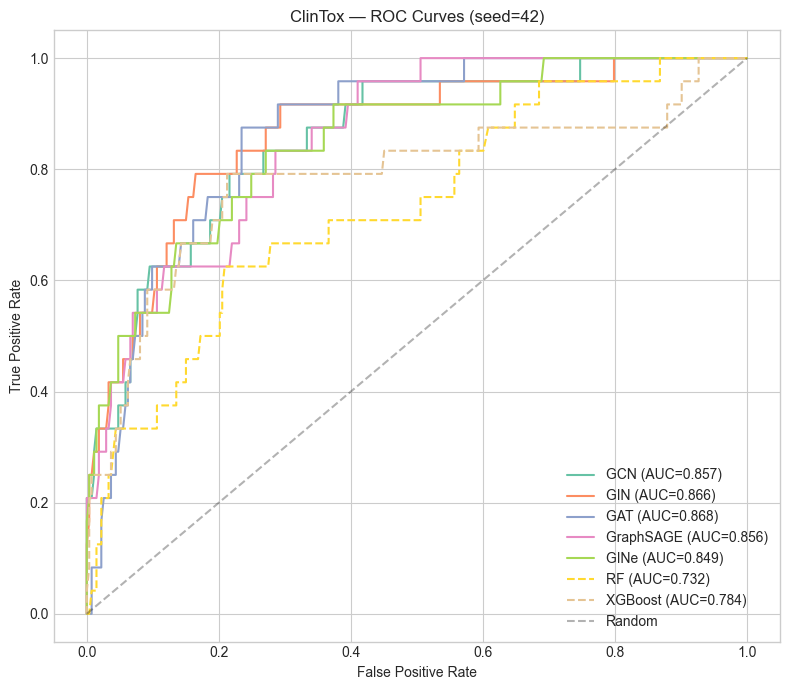

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))

# GNN models
for model_name, seed_results in clintox_results.items():
    res = next(r for r in seed_results if r["Seed"] == 42)
    fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={res['ROC AUC']:.3f})")

# Classical baselines
for model_name, seed_results in clintox_baselines.items():
    res = next(r for r in seed_results if r["Seed"] == 42)
    fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
    ax.plot(fpr, tpr, linestyle="--", label=f"{model_name} (AUC={res['ROC AUC']:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ClinTox \u2014 ROC Curves (seed=42)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/clintox_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Actual vs Predicted — LD50_Zhu (seed=42)

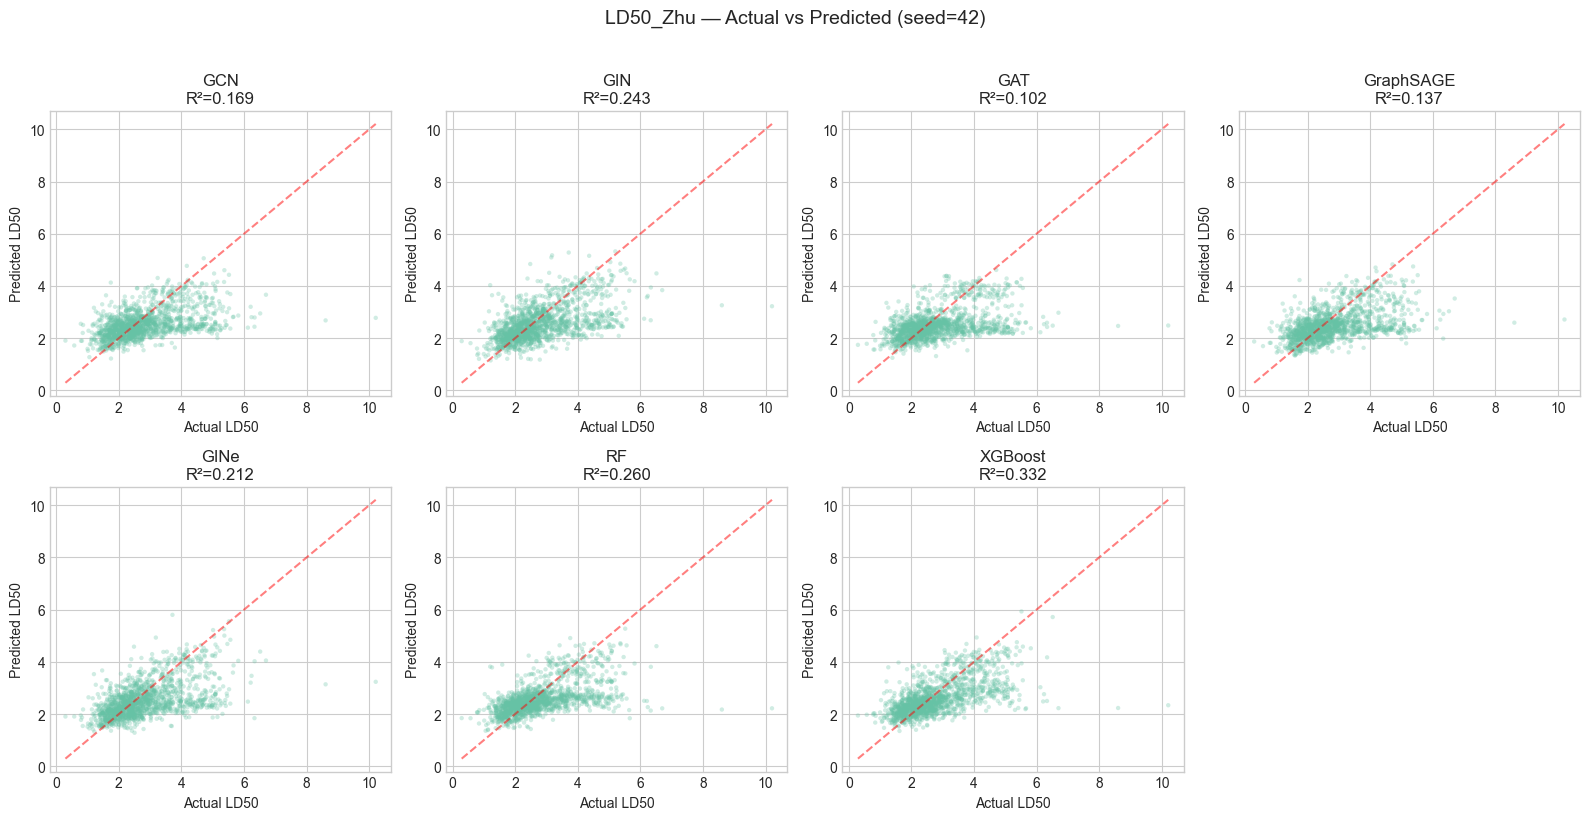

In [17]:
all_ld50_models = {**ld50_results, **ld50_baselines}
n_models = len(all_ld50_models)
cols = 4
rows_needed = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows_needed, cols, figsize=(4 * cols, 4 * rows_needed))
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for idx, (model_name, seed_results) in enumerate(all_ld50_models.items()):
    res = next(r for r in seed_results if r["Seed"] == 42)
    ax = axes_flat[idx]
    ax.scatter(res["labels"], res["preds"], alpha=0.3, s=10, edgecolors="none")

    lims = [
        min(res["labels"].min(), res["preds"].min()),
        max(res["labels"].max(), res["preds"].max()),
    ]
    ax.plot(lims, lims, "r--", alpha=0.5)
    ax.set_xlabel("Actual LD50")
    ax.set_ylabel("Predicted LD50")
    ax.set_title(f"{model_name}\nR\u00b2={res['R2']:.3f}")

for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle("LD50_Zhu \u2014 Actual vs Predicted (seed=42)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(
    f"{PLOTS_PATH}/ld50_scatter_actual_vs_predicted.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

---
## 11. Ablation — GIN vs GINe (Edge Feature Contribution)

GINe extends GIN by injecting **bond-level features** (type, conjugation, ring
membership) via `GINEConv`. This ablation quantifies whether the additional
edge information improves prediction quality.

Ablation: GIN vs GINe — Impact of Bond-Level Edge Features

ClinTox (Classification):
  GIN  AUC: 0.878 ± 0.028
  GINe AUC: 0.854 ± 0.013
  Δ AUC:    -0.024

LD50_Zhu (Regression):
  GIN  R²: -0.115 ± 0.376
  GINe R²: 0.182 ± 0.031
  Δ R²:    +0.297


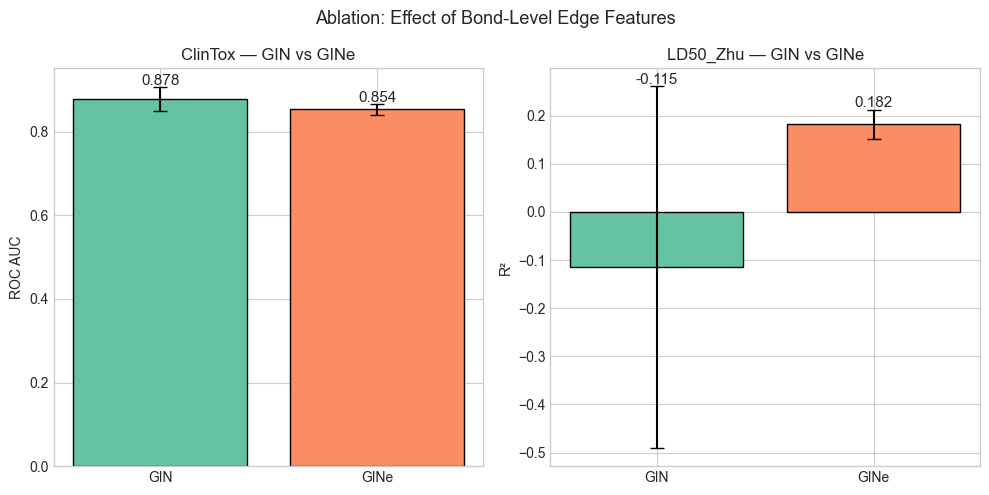

In [18]:
print("=" * 60)
print("Ablation: GIN vs GINe \u2014 Impact of Bond-Level Edge Features")
print("=" * 60)

# ClinTox
gin_auc = [r["ROC AUC"] for r in clintox_results["GIN"]]
gine_auc = [r["ROC AUC"] for r in clintox_results["GINe"]]
print(f"\nClinTox (Classification):")
print(f"  GIN  AUC: {np.mean(gin_auc):.3f} \u00b1 {np.std(gin_auc):.3f}")
print(f"  GINe AUC: {np.mean(gine_auc):.3f} \u00b1 {np.std(gine_auc):.3f}")
print(f"  \u0394 AUC:    {np.mean(gine_auc) - np.mean(gin_auc):+.3f}")

# LD50
gin_r2 = [r["R2"] for r in ld50_results["GIN"]]
gine_r2 = [r["R2"] for r in ld50_results["GINe"]]
print(f"\nLD50_Zhu (Regression):")
print(f"  GIN  R\u00b2: {np.mean(gin_r2):.3f} \u00b1 {np.std(gin_r2):.3f}")
print(f"  GINe R\u00b2: {np.mean(gine_r2):.3f} \u00b1 {np.std(gine_r2):.3f}")
print(f"  \u0394 R\u00b2:    {np.mean(gine_r2) - np.mean(gin_r2):+.3f}")

# Ablation bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

models_ab = ["GIN", "GINe"]
colors_ab = ["#66c2a5", "#fc8d62"]

aucs = [np.mean(gin_auc), np.mean(gine_auc)]
auc_stds = [np.std(gin_auc), np.std(gine_auc)]
axes[0].bar(models_ab, aucs, yerr=auc_stds, capsize=5, color=colors_ab, edgecolor="black")
for i, (v, s) in enumerate(zip(aucs, auc_stds)):
    axes[0].text(i, v + s + 0.005, f"{v:.3f}", ha="center", fontsize=11)
axes[0].set_ylabel("ROC AUC")
axes[0].set_title("ClinTox \u2014 GIN vs GINe")

r2s = [np.mean(gin_r2), np.mean(gine_r2)]
r2_stds = [np.std(gin_r2), np.std(gine_r2)]
axes[1].bar(models_ab, r2s, yerr=r2_stds, capsize=5, color=colors_ab, edgecolor="black")
for i, (v, s) in enumerate(zip(r2s, r2_stds)):
    axes[1].text(i, v + s + 0.005, f"{v:.3f}", ha="center", fontsize=11)
axes[1].set_ylabel("R\u00b2")
axes[1].set_title("LD50_Zhu \u2014 GIN vs GINe")

plt.suptitle("Ablation: Effect of Bond-Level Edge Features", fontsize=13)
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/ablation_gin_vs_gine.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 12. Save Artifacts — Model Weights & Results CSVs

In [19]:
# ── Save model weights (from last seed) ───────────────────────────────────

for model_name, model in clintox_models.items():
    path = os.path.join(MODELS_PATH, f"{model_name}_clintox.pt")
    torch.save(model.state_dict(), path)
    print(f"Saved: {path}")

for model_name, model in ld50_models.items():
    path = os.path.join(MODELS_PATH, f"{model_name}_ld50.pt")
    torch.save(model.state_dict(), path)
    print(f"Saved: {path}")

# ── Save summary CSVs ────────────────────────────────────────────────────

clintox_summary[["Model", "AUC", "F1"]].to_csv(
    os.path.join(RESULTS_PATH, "clintox_results.csv"), index=False
)
ld50_summary[["Model", "R²", "RMSE"]].to_csv(
    os.path.join(RESULTS_PATH, "ld50_results.csv"), index=False
)

# ── Save detailed per-seed results ────────────────────────────────────────

clf_rows = []
for model_name, seed_results in {**clintox_results, **clintox_baselines}.items():
    for r in seed_results:
        clf_rows.append({
            "Model": model_name, "Seed": r["Seed"],
            "ROC AUC": r["ROC AUC"], "F1 Score": r["F1 Score"],
        })
pd.DataFrame(clf_rows).to_csv(
    os.path.join(RESULTS_PATH, "clintox_detailed.csv"), index=False
)

reg_rows = []
for model_name, seed_results in {**ld50_results, **ld50_baselines}.items():
    for r in seed_results:
        reg_rows.append({
            "Model": model_name, "Seed": r["Seed"],
            "R2": r["R2"], "RMSE": r["RMSE"],
        })
pd.DataFrame(reg_rows).to_csv(
    os.path.join(RESULTS_PATH, "ld50_detailed.csv"), index=False
)

print(f"\nAll results saved to {RESULTS_PATH}/")
print(f"All model weights saved to {MODELS_PATH}/")

Saved: ../models\GCN_clintox.pt
Saved: ../models\GIN_clintox.pt
Saved: ../models\GAT_clintox.pt
Saved: ../models\GraphSAGE_clintox.pt
Saved: ../models\GINe_clintox.pt
Saved: ../models\GCN_ld50.pt
Saved: ../models\GIN_ld50.pt
Saved: ../models\GAT_ld50.pt
Saved: ../models\GraphSAGE_ld50.pt
Saved: ../models\GINe_ld50.pt

All results saved to ../results/
All model weights saved to ../models/
